# Credit Card Fraud Detection using Random Forest

## Import Libraries

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,accuracy_score,precision_recall_curve,auc,confusion_matrix,PrecisionRecallDisplay

## Load Data set

In [36]:
train_df = pd.read_csv('fraudTrain.csv')
test_df = pd.read_csv('fraudTest.csv')
drop_cols = ['is_fraud', 'Unnamed: 0', 'trans_num', 'cc_num', 'first', 'last','street', 'unix_time', 'merchant', 'job', 'city', 'state', 'zip']
Xtrain_df=train_df.drop(drop_cols,axis=1)
ytrain_df=train_df['is_fraud']
Xtest_df=test_df.drop(drop_cols,axis=1)
ytest_df=test_df['is_fraud']


# Exploratory Data Analysis(EDA)

In [37]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  str    
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  str    
 4   category               1296675 non-null  str    
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  str    
 7   last                   1296675 non-null  str    
 8   gender                 1296675 non-null  str    
 9   street                 1296675 non-null  str    
 10  city                   1296675 non-null  str    
 11  state                  1296675 non-null  str    
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long                   129667

In [38]:
train_df.describe()

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06
mean,6.483370e+05,4.171920e+17,7.035104e+01,4.880067e+04,3.853762e+01,-9.022634e+01,8.882444e+04,1.349244e+09,3.853734e+01,-9.022646e+01,5.788652e-03
std,3.743180e+05,1.308806e+18,1.603160e+02,2.689322e+04,5.075808e+00,1.375908e+01,3.019564e+05,1.284128e+07,5.109788e+00,1.377109e+01,7.586269e-02
min,0.000000e+00,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.325376e+09,1.902779e+01,-1.666712e+02,0.000000e+00
25%,3.241685e+05,1.800429e+14,9.650000e+00,2.623700e+04,3.462050e+01,-9.679800e+01,7.430000e+02,1.338751e+09,3.473357e+01,-9.689728e+01,0.000000e+00
50%,6.483370e+05,3.521417e+15,4.752000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.456000e+03,1.349250e+09,3.936568e+01,-8.743839e+01,0.000000e+00
75%,9.725055e+05,4.642255e+15,8.314000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,1.359385e+09,4.195716e+01,-8.023680e+01,0.000000e+00
max,1.296674e+06,4.992346e+18,2.894890e+04,9.978300e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.371817e+09,6.751027e+01,-6.695090e+01,1.000000e+00


In [39]:
pd.set_option('display.max_rows',None)
train_df.isnull().sum().sort_values(ascending=False)

Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

# Date & Time Feature Extraction

In [40]:
for df in [Xtrain_df, Xtest_df]:
    df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
    df['hour'] = df['trans_date_trans_time'].dt.hour
    df['day'] = df['trans_date_trans_time'].dt.day
    df['month'] = df['trans_date_trans_time'].dt.month
    df.drop(columns=['trans_date_trans_time'], inplace=True)

    df['dob'] = pd.to_datetime(df['dob'])
    df['age'] = 2026 - df['dob'].dt.year
    df.drop(columns=['dob'], inplace=True)

Xtrain_df['dob'] = pd.to_datetime(Xtrain_df['dob'])
Xtrain_df['age'] = 2026 - Xtrain_df['dob'].dt.year
Xtrain_df = Xtrain_df.drop(columns=['dob'])

Xtest_df['dob'] = pd.to_datetime(Xtest_df['dob'])
Xtest_df['age'] = 2026 - Xtest_df['dob'].dt.year
Xtest_df = Xtest_df.drop(columns=['dob'])

# One-Hot Encoding

In [ ]:
categorical_cols = ['category', 'gender']

ct = ColumnTransformer(transformers=[('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), categorical_cols)], remainder='passthrough', verbose_feature_names_out=False)

Xtrain_df = pd.DataFrame(ct.fit_transform(Xtrain_df), columns=ct.get_feature_names_out(), index=Xtrain_df.index)
Xtest_df = pd.DataFrame(ct.transform(Xtest_df), columns=ct.get_feature_names_out(), index=Xtest_df.index)

# Train the Model

In [42]:
classifier = RandomForestClassifier(n_estimators=150,max_depth=20,min_samples_split=5, min_samples_leaf=2,max_features='sqrt',class_weight='balanced',random_state=42,n_jobs=-1)
classifier.fit(Xtrain_df, ytrain_df)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",150
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_feat

# Model Prediction

In [50]:
ypred = classifier.predict(Xtest_df)
ypred_proba = classifier.predict_proba(Xtest_df)[:, 1]

# Model Evaluation

- ## Accuracy & Classification Report

In [51]:
print("Accuracy Score:", accuracy_score(ytest_df, ypred))
print("\nClassification Report:\n")
print(classification_report(ytest_df, ypred))

Accuracy Score: 0.9969732904579472

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.57      0.88      0.69      2145

    accuracy                           1.00    555719
   macro avg       0.78      0.94      0.84    555719
weighted avg       1.00      1.00      1.00    555719



- ## Confusion Matrix

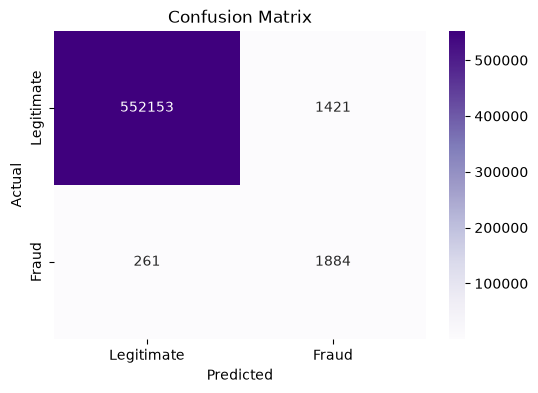

In [54]:
cm = confusion_matrix(ytest_df, ypred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

- ## Precision-Recall Curve

PR-AUC Score: 0.8610


c:\Users\khale\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\_plotting.py:193: FutureWarning: `**kwargs` is deprecated and will be removed in 1.11. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


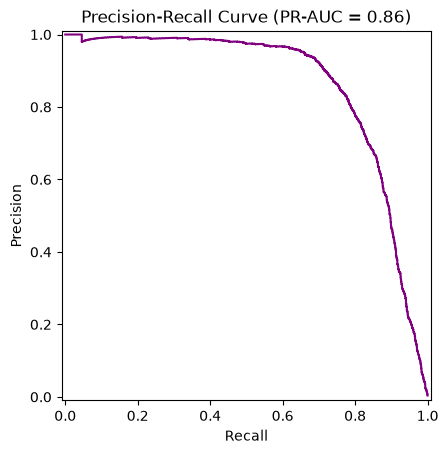

In [55]:
precision_vals, recall_vals, _ = precision_recall_curve(ytest_df, ypred_proba)

pr_auc_score = auc(recall_vals, precision_vals)
print(f"PR-AUC Score: {pr_auc_score:.4f}")

display = PrecisionRecallDisplay(
    precision=precision_vals,
    recall=recall_vals
)

display.plot(color='purple')
plt.title(f'Precision-Recall Curve (PR-AUC = {pr_auc_score:.2f})')
plt.show()